In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

unificar archivos

In [ ]:
archivos = [
    '../../datos/completo/lunes-03-11.csv',
    '../../datos/completo/martes-11-11.csv', 
    '../../datos/completo/miercoles-12-11.csv',
    '../../datos/completo/jueves-06-11.csv',
    '../../datos/completo/viernes-14-11.csv'
]

df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

gráfico con todos los semáforos

gráfico con algunos semáforos representativos (filtrados)

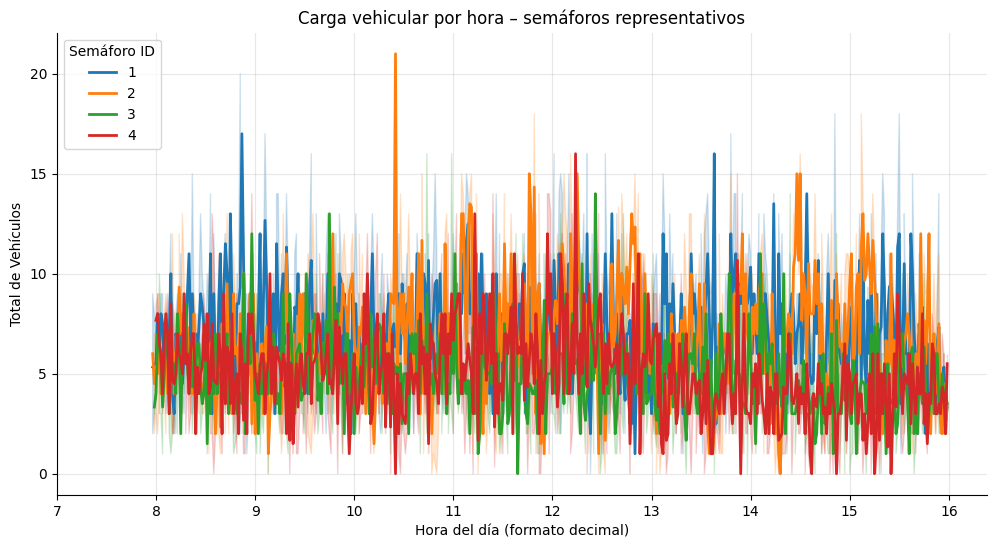

In [ ]:
semaforos_top = (
    df['Semaforo_ID']
    .value_counts()
    .nlargest(4)
    .index
)

df_filtrado = df[df['Semaforo_ID'].isin(semaforos_top)]

# carga vehicular por hora para semáforos representativos
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_filtrado,
    x='Hora_Float',
    y='Total_Vehiculos',
    hue='Semaforo_ID',
    palette='tab10',
    linewidth=2
)

plt.title('Carga vehicular por hora - semáforos representativos')
plt.xlabel('Hora del día (formato decimal)')
plt.ylabel('Total de Vehículos')
plt.xticks(range(7, 17))
plt.grid(True, alpha=0.3)
plt.legend(title='Semáforo ID')
sns.despine()
plt.show()

gráficos por cada semáforo

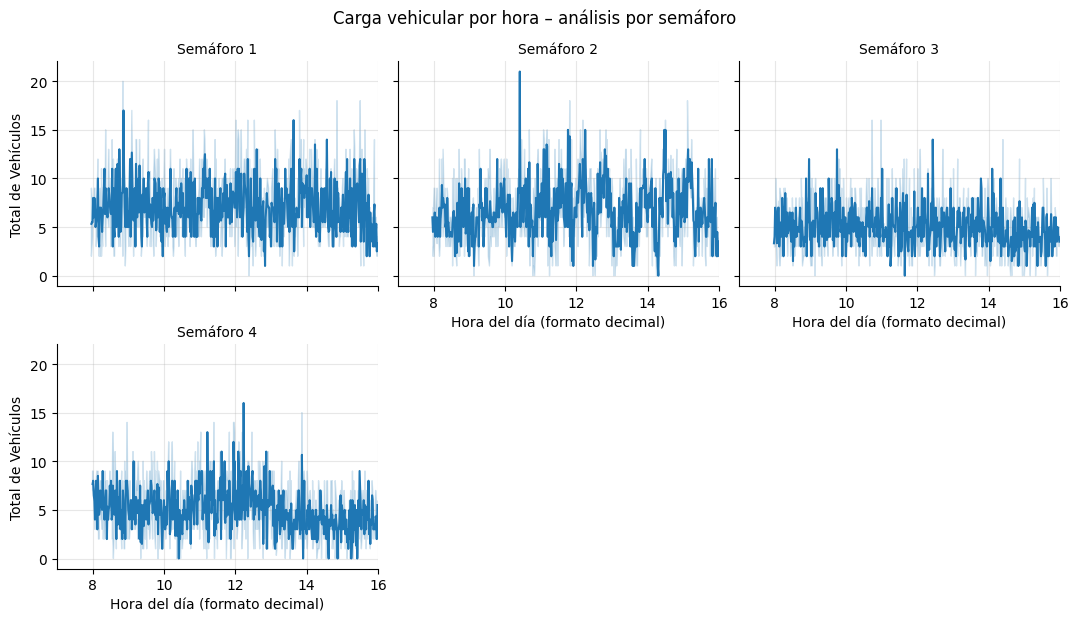

In [ ]:
# hora a formato decimal
df['Hora_Float'] = (
    pd.to_datetime(df['Hora_Inicio'], format='%H:%M:%S').dt.hour +
    pd.to_datetime(df['Hora_Inicio'], format='%H:%M:%S').dt.minute / 60
)

g = sns.relplot(
    data=df,
    x='Hora_Float',
    y='Total_Vehiculos',
    col='Semaforo_ID',
    kind='line',
    col_wrap=3,          
    height=3,           
    aspect=1.2,          
    linewidth=1.5
)


g.set_axis_labels('Hora del día', 'Total de Vehículos')
g.set_titles('Semáforo {col_name}')
g.set(xlim=(7, 16))     # rango horario 
for ax in g.axes.flatten():
    ax.grid(True, alpha=0.3)

plt.suptitle('Carga vehicular por hora - análisis por semáforo', y=1.03)
sns.despine()
plt.show()


relación ocupación espacial y volumen de vehículos

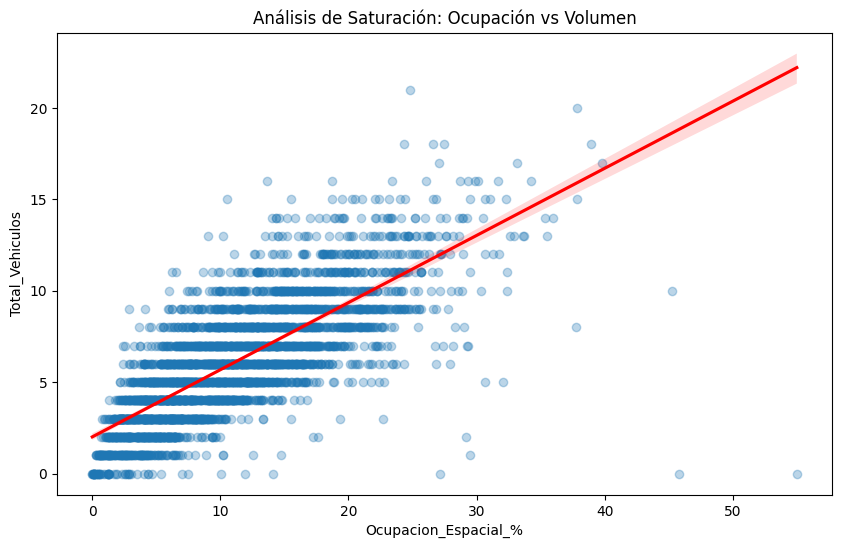

In [4]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Ocupacion_Espacial_%', y='Total_Vehiculos', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Análisis de Saturación: Ocupación vs Volumen')
plt.show()

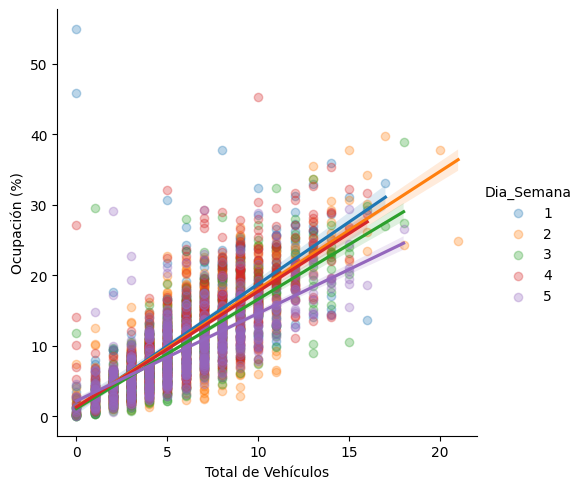

In [6]:
g = sns.lmplot(x='Total_Vehiculos', y='Ocupacion_Espacial_%', 
               hue='Dia_Semana', data=df, scatter_kws={'alpha':0.3})
g.set_axis_labels("Total de Vehículos", "Ocupación (%)")
plt.show()

análisis exploratorio de residuos según modelo lineal base

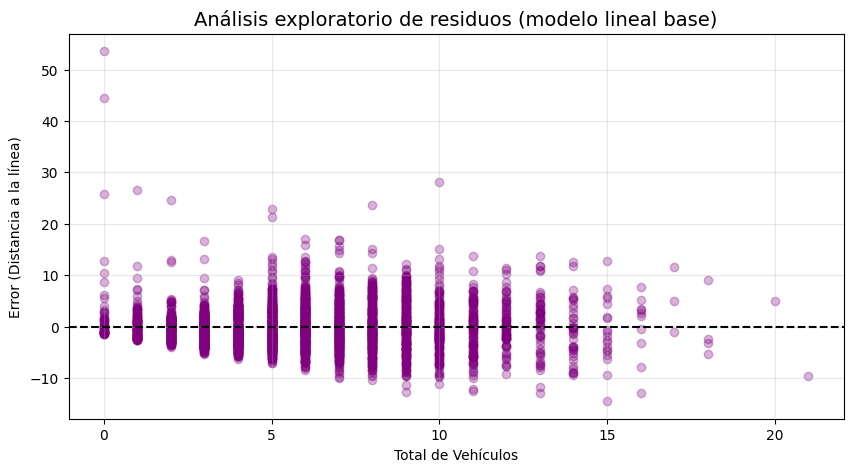

In [ ]:
z = np.polyfit(df['Total_Vehiculos'], df['Ocupacion_Espacial_%'], 1)
p = np.poly1d(z)

residuos = df['Ocupacion_Espacial_%'] - p(df['Total_Vehiculos'])


plt.figure(figsize=(10, 5))
plt.scatter(df['Total_Vehiculos'], residuos, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') 

plt.title('Análisis exploratorio de residuos', fontsize=14)
plt.xlabel('Total de Vehículos')
plt.ylabel('Error (Distancia a la línea)')
plt.grid(True, alpha=0.3)
plt.show()